# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

---

*Ноутбук выполнен целиком (`Kernel → Restart Kernel and Run All Cells`).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ.**

**1.** $C_1 = \{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$ - **выпуклый**

Это надграфик $\operatorname{epi}\varphi$ функции $\varphi(x_1) = x_1^2$, а надграфик выпуклой функции аналогично выпуклый $\varphi'' = 2 > 0$.

Проверка по чек-листу: $h(x) = x_2 - x_1^2$, гессиан $\nabla^2 h = \operatorname{diag}(-2, 0) \preceq 0$, значит $h$ вогнута, и множество $\{h \ge 0\}$ выпукло как подуровневое множество выпуклой $-h$.

Прямо по определению: для $x, y \in C_1$ и $z = (1-t)x + ty$

$$z_2 = (1-t)x_2 + t y_2 \ \ge\ (1-t)x_1^2 + t y_1^2 \ \ge\ \big((1-t)x_1 + t y_1\big)^2 = z_1^2,$$

где первое неравенство - принадлежность $x, y \in C_1$, второе - выпуклость $u \mapsto u^2$.

**2. $C_2 = \{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ — выпуклый при любых $A$, $b$.**

Функция $\psi(x) = \Vert Ax - b\Vert_2$ выпукла: норма выпукла, а композиция с аффинным отображением сохраняет выпуклость (правило 2 раздела 5). Значит $C_2 = \{\psi \le 1\}$ — подуровневое множество выпуклой функции, оно выпукло.

Никаких условий на $A$ не нужно. Множество может оказаться пустым (если $\operatorname{dist}(b, \operatorname{range} A) > 1$) или неограниченным (если $\ker A \ne \{0\}$) - на выпуклость это не влияет: пустое множество выпукло по определению, «цилиндр» вдоль ядра тоже.

**3. $C_3 = \{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$ — не выпукло.**

Контрпример: $x = (1, 0)$ и $y = (-1, 0)$ лежат в $C_3$ (обе нормы равны 1), а середина отрезка

$$\tfrac12 x + \tfrac12 y = (0, 0), \qquad \Vert(0,0)\Vert = 0 < 1,$$

в $C_3$ не лежит — отрезок вылезает наружу.

По чек-листу видно и причину, здесь $h(x) = \Vert x\Vert^2 - 1$ **выпукла**, а требуется вогнутость. Это пример из раздела 8 конспекта: одна и та же функция, но $\Vert x\Vert^2 \le 1$ даёт шар (выпуклый), а $\Vert x\Vert^2 \ge 1$ — внешность шара (невыпуклую).

**(б)**

**Ответ.**

**1. $f(x) = x_1^2 + a\,x_1x_2 + x_2^2$.**

Это квадратичная форма $f(x) = \tfrac12 x^\top Q x$ с постоянным гессианом

$$\nabla^2 f(x) = Q = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}.$$

Собственные векторы $(1,1)^\top$ и $(1,-1)^\top$, собственные числа $\lambda_{1,2} = 2 \pm a$. По критерию второго порядка $f$ выпукла $\iff Q \succeq 0 \iff \min(2+a,\, 2-a) \ge 0$:

$$\boxed{\ f \text{ выпукла} \iff |a| \le 2, \qquad f \text{ строго выпукла} \iff |a| < 2 .\ }$$

Граничные случаи нужно разобрать отдельно, потому что $\nabla^2 f \succ 0$ — условие достаточное, но **не необходимое** для строгой выпуклости (в конспекте пример $x^4$: строго выпукла, но $f''(0) = 0$). Здесь при $a = 2$ имеем $f = (x_1+x_2)^2$, и вдоль прямой $x_1 + x_2 = 0$ функция тождественно равна нулю — на этой прямой она аффинна, так что строгой выпуклости нет. Симметрично при $a = -2$: $f = (x_1-x_2)^2$ обращается в 0 на прямой $x_1 = x_2$. Значит при $|a| = 2$ функция выпукла, но не строго.

При $|a| > 2$ собственное число $2 - |a| < 0$, гессиан индефинитен, функция невыпукла. Явный контрпример при $a = 3$: вдоль направления $d = (1,-1)^\top$

$$f(td) = t^2 - 3t^2 + t^2 = -t^2$$

— парабола ветвями вниз, хорда под графиком.

**2. $g(x) = x_1^2 x_2^2$ — не выпукла на $\mathbb{R}^2$.**

Гессиан

$$\nabla^2 g(x) = \begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix}, \qquad \det \nabla^2 g = 4x_1^2x_2^2 - 16x_1^2x_2^2 = -12\,x_1^2x_2^2 .$$

При $x_1x_2 \ne 0$ определитель строго отрицателен, а для матрицы $2\times2$ это означает собственные числа разных знаков: гессиан индефинитен **всюду вне осей координат**. Критерий второго порядка не выполнен ни в одной такой точке, и одной точки достаточно.

Контрпример прямо по определению (он сильнее — не опирается на гладкость): возьмём $x = (1, 0)$, $y = (0, 1)$, $t = \tfrac12$. Тогда

$$g(x) = g(y) = 0, \qquad g\big(\tfrac12 x + \tfrac12 y\big) = g(0.5,\, 0.5) = 0.0625 \; > \; 0 = \tfrac12 g(x) + \tfrac12 g(y).$$

Хорда проходит **под** графиком. Тот же эффект есть и в положительном квадранте: для $x = (1,\,0.01)$, $y = (0.01,\,1)$ получаем $0.0001 < 0.065$ — так что ограничение области на $x > 0$ не помогает.

Почему не срабатывают правила раздела 5: $g = (x_1x_2)^2$ — композиция $s \mapsto s^2$ с $u(x) = x_1x_2$. Правило 4 требует, чтобы внешняя функция была выпуклой **и неубывающей**, а $s^2$ на $\mathbb{R}$ не монотонна. Вдобавок внутренняя $x_1x_2$ сама не выпукла (её гессиан $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ индефинитен). Это та же ловушка, что с $(x^2-1)^2$ в конспекте.

In [2]:
# 1(б)1: собственные числа гессиана Q = [[2, a], [a, 2]]
print("f(x) = x1^2 + a*x1*x2 + x2^2,   Q = [[2, a], [a, 2]]")
print(f"{'a':>6} | {'собственные числа':>22} | {'lambda_min':>11} | вывод")
for a_val in [-3.0, -2.5, -2.0, -1.0, 0.0, 1.0, 2.0, 2.5, 3.0]:
    Q = np.array([[2.0, a_val], [a_val, 2.0]])
    ev = np.linalg.eigvalsh(Q)                       # симметричная -> eigvalsh
    if ev.min() > 1e-10:
        verdict = "строго выпукла (Q > 0)"
    elif ev.min() > -1e-10:
        verdict = "выпукла, но не строго (Q >= 0, есть нулевое с.ч.)"
    else:
        verdict = "НЕ выпукла (Q индефинитна)"
    print(f"{a_val:>6.1f} | {str(np.round(ev, 4)):>22} | {ev.min():>11.4f} | {verdict}")

print("\nпри |a| = 2 функция вырождается в полный квадрат и вдоль одной прямой равна нулю:")
for a_val, d in [(2.0, np.array([1.0, -1.0])), (-2.0, np.array([1.0, 1.0]))]:
    f_quad = lambda z, a_=a_val: z[0] ** 2 + a_ * z[0] * z[1] + z[1] ** 2
    vals = [f_quad(s * d) for s in [0.0, 1.0, 2.0, 5.0]]
    print(f"  a = {a_val:+.0f}: f вдоль d = {d} равна {vals}  -> аффинна на прямой, не строго выпукла")

print("\nконтрпример при a = 3 вдоль d = (1, -1): f(t*d) = t^2 - 3t^2 + t^2 = -t^2")
d = np.array([1.0, -1.0])
print("  t:      ", [0.0, 1.0, 2.0, 3.0])
print("  f(t*d): ", [round(s**2 * (1 - 3 + 1), 4) for s in [0.0, 1.0, 2.0, 3.0]])

# 1(б)2: гессиан g(x) = x1^2 * x2^2
print("\n\ng(x) = x1^2 * x2^2,   H = [[2*x2^2, 4*x1*x2], [4*x1*x2, 2*x1^2]],  det H = -12*x1^2*x2^2")
print(f"{'x':>14} | {'собственные числа':>22} | {'det':>10}")
for pt in [[1.0, 1.0], [1.0, -1.0], [0.5, 0.5], [2.0, 0.1], [1.0, 0.0]]:
    x1, x2 = pt
    H = np.array([[2 * x2 ** 2, 4 * x1 * x2], [4 * x1 * x2, 2 * x1 ** 2]])
    print(f"{str(pt):>14} | {str(np.round(np.linalg.eigvalsh(H), 4)):>22} | {np.linalg.det(H):>10.4f}")

g = lambda z: z[0] ** 2 * z[1] ** 2
for u, v in [(np.array([1.0, 0.0]), np.array([0.0, 1.0])),
             (np.array([1.0, 0.01]), np.array([0.01, 1.0]))]:
    mid = 0.5 * (u + v)
    print(f"\nконтрпример: x = {u}, y = {v}")
    print(f"  хорда  0.5*g(x) + 0.5*g(y) = {0.5*g(u) + 0.5*g(v):.6f}")
    print(f"  график g((x+y)/2)          = {g(mid):.6f}   -> хорда НИЖЕ графика, g не выпукла")

f(x) = x1^2 + a*x1*x2 + x2^2,   Q = [[2, a], [a, 2]]
     a |      собственные числа |  lambda_min | вывод
  -3.0 |              [-1.  5.] |     -1.0000 | НЕ выпукла (Q индефинитна)
  -2.5 |            [-0.5  4.5] |     -0.5000 | НЕ выпукла (Q индефинитна)
  -2.0 |                [0. 4.] |      0.0000 | выпукла, но не строго (Q >= 0, есть нулевое с.ч.)
  -1.0 |                [1. 3.] |      1.0000 | строго выпукла (Q > 0)
   0.0 |                [2. 2.] |      2.0000 | строго выпукла (Q > 0)
   1.0 |                [1. 3.] |      1.0000 | строго выпукла (Q > 0)
   2.0 |                [0. 4.] |      0.0000 | выпукла, но не строго (Q >= 0, есть нулевое с.ч.)
   2.5 |            [-0.5  4.5] |     -0.5000 | НЕ выпукла (Q индефинитна)
   3.0 |              [-1.  5.] |     -1.0000 | НЕ выпукла (Q индефинитна)

при |a| = 2 функция вырождается в полный квадрат и вдоль одной прямой равна нулю:
  a = +2: f вдоль d = [ 1. -1.] равна [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(

**(в)**

**Ответ.**

**1. $f(x) = \Vert Ax - b\Vert_2 + \lambda \Vert x\Vert_\infty$, $\lambda \ge 0$ — выпукла.**

Из правил раздела 5:

- $\Vert \cdot \Vert_2$ выпукла (неравенство треугольника плюс однородность), отображение $x \mapsto Ax - b$ аффинно, поэтому $\Vert Ax - b\Vert_2$ выпукла по **правилу 2** (композиция с аффинным отображением);
- $\Vert x\Vert_\infty = \max_i |x_i| = \max_{i}\big(\max(x_i,\, -x_i)\big)$ — максимум $2n$ аффинных функций, выпукла по **правилу 3** (можно и короче: любая норма выпукла);
- сумма с неотрицательными коэффициентами $1$ и $\lambda \ge 0$ выпукла по **правилу 1**.

**2. $f(x) = \max_i \big(a_i^\top x - b_i\big)^2$ — выпукла.**

- Каждое слагаемое: $s \mapsto s^2$ выпукла, $x \mapsto a_i^\top x - b_i$ аффинно, значит $(a_i^\top x - b_i)^2$ выпукла по **правилу 2**. Монотонность здесь не требуется: правило 2 говорит про аффинную внутреннюю функцию и работает всегда — в отличие от правила 4, где внутренняя функция лишь выпукла и монотонность внешней обязательна.
- Максимум конечного числа выпуклых функций выпукл — **правило 3**.

Так как $s \mapsto s^2$ возрастает на $[0, \infty)$,

$$f(x) = \Big(\max_i \big\lvert a_i^\top x - b_i \big\rvert\Big)^2,$$

то есть это квадрат чебышёвской целевой функции.

**3. $f(x) = e^{-\Vert x\Vert_2^2}$ — не выпукла.**

Правило 4 **не применимо**: $f = g \circ u$ с $u(x) = \Vert x\Vert_2^2$ (выпукла) и $g(s) = e^{-s}$, которая выпукла, но **убывает**, а правило требует неубывания. Само по себе неприменение правила ещё ничего не доказывает, поэтому нужен контрпример.

При $n = 1$ возьмём $x = -1$, $y = 1$, $t = \tfrac12$:

$$\tfrac12 f(-1) + \tfrac12 f(1) = e^{-1} \approx 0.368 \; < \; 1 = f(0) = f\big(\tfrac12 x + \tfrac12 y\big)$$

— хорда под графиком. Через критерий второго порядка: $f''(x) = (4x^2 - 2)e^{-x^2}$, и $f''(0) = -2 < 0$.

Самый короткий аргумент: $0 < f(x) \le 1$ всюду, то есть $f$ ограничена сверху на всём $\mathbb{R}^n$ и при этом непостоянна. Выпуклая функция, ограниченная сверху на $\mathbb{R}^n$, обязана быть постоянной, — значит $f$ невыпукла.

**Гладкость.** Гладкая только третья: $e^{-\Vert x\Vert^2} \in C^\infty$.

- Первая негладка: $\Vert \cdot \Vert_2$ имеет излом в нуле, то есть $\Vert Ax - b\Vert_2$ негладка там, где $Ax = b$; $\Vert x\Vert_\infty$ негладка всюду, где максимум достигается больше чем на одной координате (в частности в нуле).
- Вторая негладка там, где максимум достигается сразу на двух индексах с разными градиентами. Пример в $\mathbb{R}^1$: $f(x) = \max\big(x^2, (x-2)^2\big)$ в точке $x = 1$ обе ветви равны 1, производная слева равна $2(x-2) = -2$, справа $2x = +2$ — излом.

 **Две выпуклые функции оказались негладкими, а единственная гладкая — невыпуклой.** Для оптимизации первые две гораздо удобнее, так как негладкость исправляется вспомогательными переменными, а невыпуклость — нет.

**(г)**

**Ответ.**  цель — равенства — неравенства.

**(а) Ближайшая точка прямой.** $\min_x \tfrac12\Vert x - p\Vert^2$ при $Ax = b$, где $A = \begin{pmatrix}1&1&1\\1&0&-1\end{pmatrix}$.

- цель: квадратичная с $Q = I \succ 0$ — выпукла, причём строго;
- равенства: аффинны ✓;
- неравенств нет.

**Выпукла**, строго. Отсюда следствие из раздела 6: решение единственно — что мы и получили, $x^\ast = (1/3, 1/3, 1/3)^\top$.

**(б) Диета.** $\min_x c^\top x$ при $Ax - b \ge 0$, $x \ge 0$.

- цель: линейна, значит выпукла (и вогнута) ✓;
- равенств нет;
- неравенства: все $h_i$ аффинны, а аффинная функция вогнута ✓.

**Выпукла** (это LP, а LP выпукла всегда). Строгой выпуклости нет: цель линейна, поэтому решений в принципе может быть целый отрезок или грань. В нашем экземпляре решение оказалось единственным, зато вершина была вырожденной.

**(в) Прямоугольник наибольшей площади в единичном круге.** $\min_x -4x_1x_2$ при $x_1^2 + x_2^2 - 1 = 0$, $x \ge 0$.

**Невыпукла**, и чек-лист ломается сразу в двух местах:

1. **Равенство не аффинно.** Теорема раздела 6 требует аффинности равенств,  допустимое множество — дуга окружности, а отрезок между $(1,0)$ и $(0,1)$ с неё сходит (середина $(0.5, 0.5)$ имеет норму $\approx 0.707 \ne 1$).
2. **Цель невыпукла.** $-4x_1x_2 = \tfrac12 x^\top Q x$ с $Q = \begin{pmatrix} 0 & -4 \\ -4 & 0\end{pmatrix}$, собственные числа $\pm 4$ — гессиан индефинитен.

Ослабление $x_1^2 + x_2^2 \le 1$ чинит только первую причину: тогда $h(x) = 1 - \Vert x\Vert^2$ вогнута и множество (четверть круга) выпукло, но цель остаётся невыпуклой, и задача выпуклой не становится. Решение при этом не меняется — оно всё равно на границе.

**(г) Нелинейный МНК $\varphi(t;x) = x_1\sin(x_2 t + x_3)$.** Безусловная задача.

- множество: $\Omega = \mathbb{R}^3$ выпукло ✓;
- цель: **невыпукла** — это и ломает задачу.

**Невыпукла.** $f$ периодична по $x_3$ с периодом $2\pi$, то есть вдоль направления $e_3$ ограничена. Но выпуклая функция, ограниченная сверху на прямой, постоянна на этой прямой, — а $f$ по $x_3$ явно непостоянна (проверено в задаче 2(б): $f = 31.9$ и $f = 40.4$ при $x_3 = 0$ и $x_3 = 1.5$). Значит $f$ невыпукла.

**(д, бонус) Чебышёвская подгонка.** Ответ «выпукла» верен для **обеих** записей:

- исходная $\min_x \max_i\lvert a_i^\top x - b_i\rvert$ — выпукла (модуль аффинной функции выпукл по правилам 2 и 3, максимум выпуклых выпукл), но **негладкая**;
- переформулировка $\min_{x,s} s$ при $-s \le a_i^\top x - b_i \le s$ — выпукла и **гладкая**: цель линейна, все ограничения аффинны, то есть это LP.

Вспомогательная переменная не создала выпуклость — та была с самого начала, — а сохранила её и добавила гладкость. Переводим выпуклую негладкую задачу в выпуклую гладкую.

**Итог.** Из пяти задач ДЗ 1 выпуклы **(а), (б), (д)**; невыпуклы **(в)** и **(г)**. В (в) виноваты нелинейное равенство и индефинитная цель, в (г) — только целевая функция.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ.**

Задача $\min_{x \in \Omega} f(x)$ с $f(x) = \tfrac12\Vert x - p\Vert^2$ и $\Omega = \{x : a^\top x \le b\}$ выпукла: $f$ строго выпукла ($\nabla^2 f = I \succ 0$), $\Omega$ — полупространство, то есть выпуклое множество. Значит решение существует, единственно, и теорема раздела 7 применима **в обе стороны**: условие

$$\nabla f(x^\ast)^\top (y - x^\ast) \ge 0 \quad \forall\, y \in \Omega, \qquad \nabla f(x) = x - p,$$

не только необходимо, но и достаточно. Поэтому достаточно **угадать** кандидата и проверить для него условие.

**(i) Решение лежит на границе.** Пусть $a^\top x^\ast < b$ строго. Рассмотрим точки $x(\tau) = x^\ast + \tau(p - x^\ast)$ при малых $\tau > 0$: по непрерывности $a^\top x(\tau) < b$, то есть они допустимы, а

$$\Vert x(\tau) - p\Vert = (1-\tau)\,\Vert x^\ast - p\Vert < \Vert x^\ast - p\Vert$$

(строго, поскольку $x^\ast \ne p$: ведь $p \notin \Omega$). Значит $x^\ast$ не оптимальна — противоречие. Следовательно

$$a^\top x^\ast = b .$$

**(ii) Ошибка ортогональна гиперплоскости.** Пусть $v$ — любой вектор с $a^\top v = 0$. Тогда обе точки $y = x^\ast \pm v$ допустимы:

$$a^\top(x^\ast \pm v) = a^\top x^\ast \pm 0 = b \le b .$$

Подставим их в условие оптимальности: $(x^\ast - p)^\top(\pm v) \ge 0$ — сразу оба знака, значит

$$(x^\ast - p)^\top v = 0 \quad \text{для всех } v \perp a .$$

То есть $x^\ast - p$ ортогонален всей гиперплоскости $a^\perp$, а её ортогональное дополнение — прямая, натянутая на $a$. Следовательно

$$x^\ast - p = -\alpha\, a \quad \text{для некоторого } \alpha \in \mathbb{R}.$$

**(iii) Находим $\alpha$.** Подставляем $x^\ast = p - \alpha a$ в $a^\top x^\ast = b$ из шага (i):

$$a^\top p - \alpha\,\Vert a\Vert^2 = b \quad\Longrightarrow\quad \alpha = \frac{a^\top p - b}{\Vert a\Vert^2},$$

и деление законно, потому что $a \ne 0$. Итого

$$\boxed{\; x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a \;}$$

**(iv) Проверка достаточности.** Шаги (i)–(iii) показали лишь, что *если* решение существует, то оно такое. Проверим условие оптимальности для этого кандидата напрямую. Для любого $y \in \Omega$

$$\nabla f(x^\ast)^\top (y - x^\ast) = (x^\ast - p)^\top (y - x^\ast) = (-\alpha a)^\top (y - x^\ast) = -\alpha\,\big(a^\top y - \underbrace{a^\top x^\ast}_{=\,b}\big) = -\alpha\,\big(a^\top y - b\big).$$

Здесь $\alpha > 0$, потому что по условию $a^\top p > b$, а $a^\top y - b \le 0$, потому что $y \in \Omega$. Произведение двух множителей с учётом минуса неотрицательно:

$$\nabla f(x^\ast)^\top (y - x^\ast) \ge 0 \quad \forall\, y \in \Omega . \qquad \checkmark$$

По теореме раздела 7 это и означает, что $x^\ast$ — **глобальное** решение, а из строгой выпуклости $f$ — что оно единственное.

**Геометрия и расстояние.** Формула говорит: идём из $p$ вдоль $-a$ (нормали, направленной внутрь полупространства) ровно настолько, чтобы попасть на гиперплоскость. Пройденное расстояние

$$\Vert x^\ast - p\Vert = \alpha\,\Vert a\Vert = \frac{a^\top p - b}{\Vert a\Vert}$$

— знакомая формула расстояния от точки до гиперплоскости.

**Для данных задачи:** $a = (1,2,-1)^\top$, $b = 1$, $p = (3,1,0.5)^\top$, откуда $a^\top p = 4.5$, $\Vert a\Vert^2 = 6$,

$$\alpha = \frac{4.5 - 1}{6} = \frac{7}{12}, \qquad x^\ast = \left(\frac{29}{12},\; -\frac16,\; \frac{13}{12}\right)^\top \approx (2.4167,\; -0.1667,\; 1.0833)^\top,$$

расстояние $\tfrac{7}{12}\sqrt6 \approx 1.4289$.

**Численная проверка (пункты 2 и 3)**

In [4]:
# --- пункт 2: формула против SLSQP ---
alpha = (a @ p - b) / (a @ a)
x_star = p - alpha * a

res = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=np.zeros(3), method="SLSQP",
               jac=lambda x: x - p,
               constraints=[{"type": "ineq",                 # SLSQP: 'ineq' означает c(x) >= 0
                             "fun": lambda x: b - a @ x,     # b - a^T x >= 0  <=>  a^T x <= b
                             "jac": lambda x: -a}])

print("alpha = (a@p - b)/||a||^2 =", alpha, " = 7/12 =", 7 / 12)
print("формула x* =", x_star)
print("SLSQP    x* =", res.x, f"   (success={res.success})")
print("расхождение ||x_формула - x_SLSQP|| =", np.linalg.norm(res.x - x_star))
print("\nпроверка допустимости и границы: a@x* =", a @ x_star, " b =", b)
print("расстояние ||x*-p|| =", np.linalg.norm(x_star - p),
      " = (a@p-b)/||a|| =", (a @ p - b) / np.linalg.norm(a))
print("f(x*) =", 0.5 * np.sum((x_star - p) ** 2))

# --- пункт 3: проверка условия оптимальности на случайных допустимых точках ---
def random_feasible(n_pts, half_width=4.0):
    # равномерно в кубе, оставляем только те точки, где a@y <= b (отбраковка)
    kept = []
    while sum(len(k) for k in kept) < n_pts:
        Y = rng.uniform(-half_width, half_width, (4000, 3))
        kept.append(Y[Y @ a <= b])
    return np.vstack(kept)[:n_pts]

Y = random_feasible(2000)
print(f"\nсгенерировано допустимых точек: {len(Y)} (все удовлетворяют a@y <= b: {np.all(Y @ a <= b)})")

for name, x_probe in [("x*  (кандидат в решения)", x_star), ("x = 0 (заведомо не решение)", np.zeros(3))]:
    grad = x_probe - p                      # grad f(x) = x - p
    vals = (Y - x_probe) @ grad
    print(f"\n{name}:  f = {0.5*np.sum((x_probe-p)**2):.6f}")
    print(f"  min_y  grad^T (y - x) = {vals.min():+.6e}")
    print(f"  доля точек с отрицательным значением: {np.mean(vals < 0):.1%} ({np.sum(vals < 0)}/{len(Y)})")

# для x = 0 достаточно одного явного направления убывания
grad0 = np.zeros(3) - p
print(f"\nдля x = 0 хватает одной пробной точки y = x*:  grad^T (x* - 0) = {grad0 @ (x_star - np.zeros(3)):.6f} < 0")

alpha = (a@p - b)/||a||^2 = 0.5833333333333334  = 7/12 = 0.5833333333333334
формула x* = [ 2.41666667 -0.16666667  1.08333333]
SLSQP    x* = [ 2.41666667 -0.16666667  1.08333333]    (success=True)
расхождение ||x_формула - x_SLSQP|| = 8.308148362110449e-16

проверка допустимости и границы: a@x* = 0.9999999999999996  b = 1.0
расстояние ||x*-p|| = 1.4288690166235207  = (a@p-b)/||a|| = 1.4288690166235207
f(x*) = 1.0208333333333337

сгенерировано допустимых точек: 2000 (все удовлетворяют a@y <= b: True)

x*  (кандидат в решения):  f = 1.020833
  min_y  grad^T (y - x) = +9.287924e-04
  доля точек с отрицательным значением: 0.0% (0/2000)

x = 0 (заведомо не решение):  f = 5.125000
  min_y  grad^T (y - x) = -1.384142e+01
  доля точек с отрицательным значением: 34.8% (697/2000)

для x = 0 хватает одной пробной точки y = x*:  grad^T (x* - 0) = -7.625000 < 0


**Ответ.**

**Пункт 2.** `SLSQP` приходит в ту же точку, что даёт формула: $x^\ast \approx (2.4167,\; -0.1667,\; 1.0833)^\top$, расхождение порядка $10^{-16}$ — уровень машинной точности. Ограничение активно ($a^\top x^\ast = b = 1$), как и предсказывал шаг (i) вывода, а расстояние равно $\tfrac{7}{12}\sqrt6 \approx 1.4289$.

**Пункт 3.**

Величина $\nabla f(x)^\top(y - x)$ — это производная $f$ в точке $x$ по направлению $y - x$, то есть скорость изменения $f$ в первом порядке, если из $x$ пойти в сторону допустимой точки $y$.

- **Для $x^\ast$:** минимум по 2000 случайным допустимым $y$ оказался равен $\approx +9.3\cdot10^{-4} > 0$, отрицательных значений нет ни одного. Ни одно допустимое направление не убывает — значит ни один малый допустимый шаг не уменьшает $f$. Для выпуклой задачи теорема раздела 7 работает в обе стороны, поэтому такое $x^\ast$ — **глобальный** минимум, а не «какой-то» локальный. Минимум близок к нулю, а не велик: среди случайных точек попадаются почти лежащие на границе $a^\top y = b$, а для них произведение $-\alpha(a^\top y - b)$ почти нулевое. Направления вдоль гиперплоскости — «нейтральные», и в них условие выполняется с равенством.

- **Для $x = 0$** (точка допустимая: $a^\top 0 = 0 \le 1$): минимум равен $\approx -13.84 < 0$, причём отрицательное значение дают примерно 35% случайных точек. Это **сертификат неоптимальности**: найдено допустимое направление убывания, значит сделав по нему малый шаг, мы строго уменьшим $f$ и останемся в $\Omega$. Достаточно даже одной пробной точки — например $y = x^\ast$, для которой $\nabla f(0)^\top(x^\ast - 0) = -7.625 < 0$. И действительно $f(0) = 5.125 > 1.021 = f(x^\ast)$.

Асимметрия здесь принципиальная, и о ней говорится в разделе 11 конспекта («не найти контрпример не значит доказать»):

- отрицательное значение **доказывает** неоптимальность — достаточно одного контрпримера;
- неотрицательность на 2000 случайных точек **ничего не доказывает**: условие требуется для *всех* $y \in \Omega$, а выборка конечна. Это лишь проверка на отсутствие грубой ошибки.

Настоящее доказательство — аналитическая выкладка шага (iv): там неравенство проверено сразу для всех $y \in \Omega$ одной строчкой.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

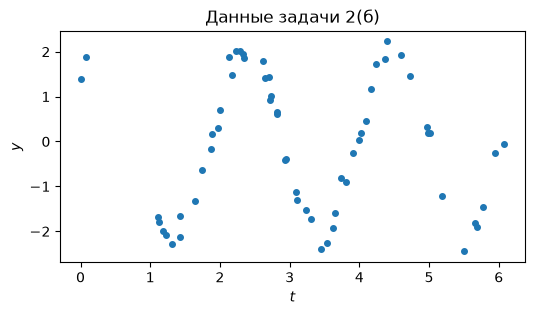

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ.**

**Модель B: $\varphi_B(t;x) = x_1\sin\omega t + x_2\cos\omega t$ при известном $\omega = 3$ — выпуклая задача.**

Модель линейна по параметрам, поэтому невязки аффинны: $r_i(x) = a_i^\top x - y_i$ с $a_i = (\sin\omega t_i,\; \cos\omega t_i)^\top$. Собирая строки в матрицу $A \in \mathbb{R}^{60\times2}$, получаем

$$f_B(x) = \tfrac12\Vert Ax - y\Vert^2 = \tfrac12 x^\top (A^\top A)\, x - (A^\top y)^\top x + \tfrac12\Vert y\Vert^2 .$$

Это **безусловная выпуклая QP** (линейный МНК, раздел 7.1 лекции 1). Доказательство выпуклости — критерий второго порядка: гессиан $\nabla^2 f_B = A^\top A$ не зависит от $x$, и для любого $v$

$$v^\top A^\top A\, v = \Vert Av\Vert^2 \ge 0 \quad\Longrightarrow\quad A^\top A \succeq 0 .$$

Более того, здесь $A$ имеет полный столбцовый ранг (проверено численно: $\operatorname{rank} A = 2$, собственные числа $A^\top A$ равны $\approx 28.16$ и $31.84$, обе строго положительны), поэтому $\Vert Av\Vert^2 > 0$ при $v \ne 0$, то есть $A^\top A \succ 0$ и $f_B$ **строго выпукла**. По следствиям раздела 6: решение существует и **единственно**, и любой локальный минимум глобален.

**Модель A: $\varphi_A(t;x) = x_1\sin(x_2 t + x_3)$ — невыпуклая задача.**

Класс: **безусловная NLP** (нелинейный МНК), $\Omega = \mathbb{R}^3$ выпукло, но целевая функция невыпукла. Две симметрии из подсказки:

$$f_A(x_1, x_2, x_3 + 2\pi) = f_A(x_1, x_2, x_3), \qquad f_A(-x_1,\, x_2,\, x_3 + \pi) = f_A(x_1, x_2, x_3),$$

первая — потому что синус $2\pi$-периодичен, вторая — потому что $\sin(\theta + \pi) = -\sin\theta$, и минус переезжает на амплитуду. Есть и третья, в подсказке не названная: синус нечётен, поэтому $f_A(-x_1, -x_2, -x_3) = f_A(x_1, x_2, x_3)$. Все три проверены численно ниже — значения совпадают до 10 знаков.

Из каждой получается доказательство невыпуклости.

*Через периодичность.* Вдоль направления $e_3$ функция $s \mapsto f_A(x_1, x_2, x_3 + s)$ периодична, значит ограничена сверху. Выпуклая функция, ограниченная сверху на прямой, постоянна на ней. Но $f_A$ по $x_3$ непостоянна ($f_A(2,3,0) \approx 31.88$ против $f_A(2,3,1.5) \approx 40.41$). Значит $f_A$ невыпукла.

*Через множество решений.* Обе симметрии переводят минимум в минимум, поэтому у $f_A$ есть **изолированные различные** глобальные минимизаторы с одинаковым значением: если $x^\ast$ — решение, то и $(-x_1^\ast, x_2^\ast, x_3^\ast + \pi)$ тоже. По следствию раздела 6 множество решений выпуклой задачи **выпукло**, и вместе с двумя точками ему принадлежал бы весь отрезок между ними — а середина отрезка здесь имеет амплитуду, далёкую от оптимальной, и решением не является. Противоречие. (Мультистарт ниже находит обе точки зеркальной пары явно.)

Итого: **B выпукла и строго выпукла, A невыпукла**, хотя описывают они один и тот же сигнал.

**Мультистарт (пункт 2)**

B:  A^T A =
 [[28.5632 -1.1463]
 [-1.1463 31.4368]]
    собственные числа: [28.1619 31.8381]    rank(A) = 2
    -> A^T A > 0, f_B строго выпукла, минимум единственный

A:  f(x1, x2, x3)        = 1.2992760360
    f(x1, x2, x3 + 2pi)  = 1.2992760360
    f(-x1, x2, x3 + pi)  = 1.2992760360
    f(-x1, -x2, -x3)     = 1.2992760360   <- третья симметрия: синус нечётен
    но по x3 функция непостоянна: f(2,3,0) = 31.8752, f(2,3,1.5) = 40.4108

  k |                        старт |        f_A |                          x_A |        f_B
  0 | [  -1.863   -3.822    1.632] |    1.13927 | [  -2.101   -2.997   -0.700] |    1.14076
  1 | [   3.197   -0.270    0.583] |   63.82490 | [  26.084   -0.002    0.004] |    1.14076
  2 | [   4.585    1.989    2.450] |    1.13927 | [  -2.101    2.997   -2.441] |    1.14076
  3 | [   3.895   -2.842    1.502] |    1.13927 | [   2.101   -2.997    2.441] |    1.14076
  4 | [   2.174    3.422   -1.562] |    1.13927 | [   2.101    2.997    0.700] |    1.14076
  5 | [

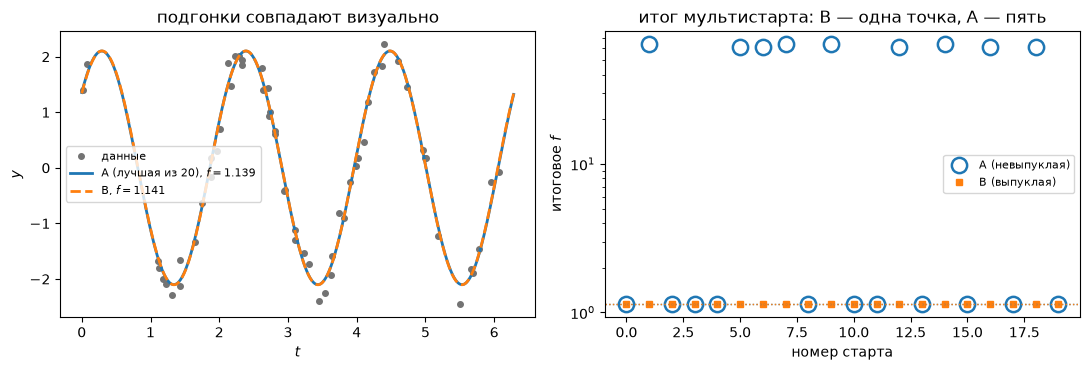

In [6]:
# целевые функции обеих моделей
f_A = lambda x: 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2)
A_mat = np.column_stack([np.sin(omega * t), np.cos(omega * t)])   # строки a_i = (sin wt_i, cos wt_i)
f_B = lambda x: 0.5 * np.sum((A_mat @ x - y) ** 2)

# --- выпуклость B: гессиан A^T A ---
H_B = A_mat.T @ A_mat
print("B:  A^T A =\n", np.round(H_B, 4))
print("    собственные числа:", np.round(np.linalg.eigvalsh(H_B), 4),
      "   rank(A) =", np.linalg.matrix_rank(A_mat))
print("    -> A^T A > 0, f_B строго выпукла, минимум единственный")

# --- симметрии A ---
x_chk = np.array([2.0, 3.0, 0.7])
print(f"\nA:  f(x1, x2, x3)        = {f_A(x_chk):.10f}")
print(f"    f(x1, x2, x3 + 2pi)  = {f_A(x_chk + np.array([0, 0, 2*np.pi])):.10f}")
print(f"    f(-x1, x2, x3 + pi)  = {f_A(np.array([-x_chk[0], x_chk[1], x_chk[2] + np.pi])):.10f}")
print(f"    f(-x1, -x2, -x3)     = {f_A(-x_chk):.10f}   <- третья симметрия: синус нечётен")
print(f"    но по x3 функция непостоянна: f(2,3,0) = {f_A(np.array([2.0,3.0,0.0])):.4f}, "
      f"f(2,3,1.5) = {f_A(np.array([2.0,3.0,1.5])):.4f}")

# --- мультистарт из общих 20 стартов ---
res_A = [minimize(f_A, s, method="BFGS") for s in starts]
res_B = [minimize(f_B, s[:2], method="BFGS") for s in starts]      # для B — первые две координаты
fA_vals = np.array([r.fun for r in res_A])
fB_vals = np.array([r.fun for r in res_B])

fmt3 = lambda v: "[" + " ".join(f"{ci:8.3f}" for ci in v) + "]"
print(f"\n{'k':>3} | {'старт':>28} | {'f_A':>10} | {'x_A':>28} | {'f_B':>10}")
for k in range(len(starts)):
    print(f"{k:>3} | {fmt3(starts[k]):>28} | {fA_vals[k]:>10.5f} | "
          f"{fmt3(res_A[k].x):>28} | {fB_vals[k]:>10.5f}")

TOL = 1e-6
bestA, bestB = fA_vals.min(), fB_vals.min()
okA, okB = np.abs(fA_vals - bestA) < TOL, np.abs(fB_vals - bestB) < TOL
print(f"\nA: наименьшее найденное f = {bestA:.6f}; дошли {okA.sum()}/20 стартов = {okA.mean():.0%}")
uniq_fA = sorted(float(v) for v in np.unique(np.round(fA_vals, 4)))
print(f"   различных предельных значений f: {len(uniq_fA)} -> {uniq_fA}")
print(f"B: наименьшее найденное f = {bestB:.6f}; дошли {okB.sum()}/20 стартов = {okB.mean():.0%}")
print(f"   различных предельных значений f: {len(np.unique(np.round(fB_vals, 4)))}")
x_B = res_B[int(np.argmin(fB_vals))].x
print(f"   разброс решений B по стартам: max||x - x_best|| = "
      f"{max(np.linalg.norm(r.x - x_B) for r in res_B):.2e}")

# зеркальная пара среди успешных стартов A
sols = np.unique(np.round(np.array([res_A[k].x for k in np.where(okA)[0]]), 4), axis=0)
print(f"\nточки, в которые пришли {int(okA.sum())} успешных стартов A "
      f"(различных: {len(sols)}, значение f у всех одно):")
for x_sol in sols:
    print(f"   x = {fmt3(x_sol)},  f = {f_A(x_sol):.6f}")
print("   это изолированные точки, связанные симметриями, а не выпуклое множество")

# --- перевод решения B в параметры модели A ---
R, phi = np.hypot(x_B[0], x_B[1]), np.arctan2(x_B[1], x_B[0])
print(f"\nB -> A:  x_B = {np.round(x_B, 4)}  =>  R = sqrt(x1^2+x2^2) = {R:.4f}, "
      f"phi = atan2(x2, x1) = {phi:.4f}")
print(f"         f_A(R, omega, phi) = {f_A(np.array([R, omega, phi])):.6f}  = f_B = {f_B(x_B):.6f}")
print(f"         истинные параметры данных: амплитуда 2.0, частота 3.0, фаза 0.7")
print(f"\nразность наименьших значений: f_B - f_A = {bestB - bestA:.6f} "
      f"({(bestB - bestA)/bestB:.2%} от f_B)")
print(f"частота, подобранная моделью A: {res_A[int(np.argmin(fA_vals))].x[1]:.6f} (истинная 3.0)")

# --- графики ---
grid = np.linspace(0, 2 * np.pi, 500)
xA_best = res_A[int(np.argmin(fA_vals))].x
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].plot(t, y, "o", ms=4, color="0.45", label="данные")
ax[0].plot(grid, xA_best[0] * np.sin(xA_best[1] * grid + xA_best[2]), lw=2,
           label=f"A (лучшая из 20), $f={bestA:.3f}$")
ax[0].plot(grid, x_B[0] * np.sin(omega * grid) + x_B[1] * np.cos(omega * grid), "--", lw=2,
           label=f"B, $f={bestB:.3f}$")
ax[0].set_xlabel("$t$"); ax[0].set_ylabel("$y$"); ax[0].legend(fontsize=8)
ax[0].set_title("подгонки совпадают визуально")

ax[1].semilogy(range(20), fA_vals, "o", ms=11, mfc="none", mew=1.8, label="A (невыпуклая)")
ax[1].semilogy(range(20), fB_vals, "s", ms=5, label="B (выпуклая)")
ax[1].axhline(bestA, color="C0", ls=":", lw=1)
ax[1].axhline(bestB, color="C1", ls=":", lw=1)
ax[1].set_xlabel("номер старта"); ax[1].set_ylabel("итоговое $f$")
ax[1].set_title("итог мультистарта: B — одна точка, A — пять"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Объяснение (пункт 3)**

**Ответ.**

**Результат мультистарта.**

| | класс | выпуклость | наименьшее $f$ | доля стартов, дошедших до него | различных пределов |
|---|---|---|---|---|---|
| A | безусловная NLP | нет | $1.139273$ | $11/20 = 55\%$ | 5 |
| B | безусловная QP | да, строго | $1.140764$ | $20/20 = 100\%$ | 1 |

**Объяснение через главную теорему.** Теорема раздела 6: *в выпуклой задаче любой локальный минимум глобален.*

Для **B** задача выпукла и строго выпукла, поэтому решение единственно, и точка с $\nabla f_B = 0$ — сразу глобальный минимум (следствие раздела 7 для безусловного случая). BFGS сходится к стационарной точке, а стационарная точка здесь ровно одна — вот все 20 стартов и приходят в неё, причём не «примерно в одно значение $f$», а буквально в одну точку: разброс решений по стартам $\sim 10^{-7}$. Старт влияет только на число итераций, но не на ответ — это в точности утверждение раздела 8.

Для **A** теорема неприменима, и $\nabla f_A = 0$ остаётся лишь *необходимым* условием. Ландшафт распадается на несколько «ям», и каждый старт скатывается в свою: получилось 5 различных предельных значений. Причём 9 стартов из 20 застряли в области $f \approx 61.5\ldots64.3$ — это фактически отказ от сигнала: там подобранная амплитуда близка к нулю (0.10–0.45) при случайной частоте, и невязка почти равна «нулевой модели» $\tfrac12\sum_i y_i^2 = 64.42$. То есть почти половина запусков даёт не «чуть худший», а бессмысленный ответ.

Отдельно стоит посмотреть, **какие именно** точки нашли 11 успешных стартов: это **семь различных точек**, и у всех семи одно и то же значение $f = 1.139273$. Все они связаны тремя симметриями модели:

- $(2.101,\, 2.997,\, 0.700)$ и $(-2.101,\, 2.997,\, -2.441)$ — зеркальная пара из $(x_1, x_3) \to (-x_1, x_3 + \pi)$: действительно $-2.441 + \pi = 0.700$;
- $(-2.101,\, -2.997,\, -0.700)$ — та же подгонка через нечётность синуса, $(x_1, x_2, x_3) \to (-x_1, -x_2, -x_3)$;
- $(2.101,\, 2.997,\, 6.983)$ — сдвиг фазы на $2\pi$.

Семь **изолированных** глобальных минимизаторов — прямое наблюдение невыпуклости: множество решений выпуклой задачи обязано быть выпуклым, а здесь оно состоит из отдельных точек, между которыми лежат точки с заметно большим $f$.

**Как из решения B получить амплитуду и фазу для A.** По формуле сложения

$$x_1\sin\omega t + x_2\cos\omega t = R\,\sin(\omega t + \phi), \qquad R = \sqrt{x_1^2 + x_2^2}, \quad \phi = \operatorname{atan2}(x_2, x_1),$$

(раскрывая правую часть, получаем $R\cos\phi\,\sin\omega t + R\sin\phi\,\cos\omega t$, откуда $x_1 = R\cos\phi$, $x_2 = R\sin\phi$). Для найденного $x_B = (1.6234,\, 1.3378)$ это даёт $R = 2.1036$, $\phi = 0.6892$, то есть параметры модели A равны $(R, \omega, \phi) = (2.1036,\; 3,\; 0.6892)$ — сравните с истинными $(2,\; 3,\; 0.7)$. Проверка в ноутбуке: $f_A(2.1036,\, 3,\, 0.6892) = 1.140764$ — в точности $f_B$, как и должно быть.

Это и есть содержательный смысл модели B: **та же самая модель A, но с перепараметризацией**, которая при фиксированной частоте делает задачу линейной по параметрам. Амплитуда и фаза никуда не делись — они просто вычисляются из решения, а не ищутся напрямую.

**Почему наименьшее $f$ у A чуть меньше.** Потому что B — это A с **замороженной** частотой $x_2 = \omega = 3$. Семейство функций, доступных модели B, есть подмножество семейства, доступного модели A:

$$\{R\sin(3t + \phi)\} \subset \{R\sin(\omega' t + \phi)\},$$

а минимум по большему множеству не может быть больше минимума по меньшему. Отсюда неравенство $f_A^{\min} \le f_B^{\min}$ выполняется автоматически, при любых данных — тот же аргумент вложенности, что и для обучающей ошибки в задаче 2(а) ДЗ 1.

**Почему это не делает A «лучшей» задачей.** Выигрыш составляет $f_B - f_A = 0.00149$, то есть $0.13\%$ — и получен он тем, что A подобрала частоту $2.9967$ вместо истинной $3$. Истинная частота данных равна ровно 3, значит эти $0.13\%$ — подгонка под конкретную реализацию шума, то есть переобучение, а не улучшение модели. Цена этого выигрыша:

- потеряна гарантия глобальности: найденное решение не сертифицируемо, мы знаем только, что это *какой-то* локальный минимум;
- ответ зависит от старта, и 45% запусков дают заведомо негодный результат;
- чтобы надёжно решать A, нужен мультистарт или разумная инициализация частоты — то есть дополнительная работа и дополнительные допущения.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ.**

**Постановка.** $\Omega \subset \mathbb{R}^n$ выпукло и замкнуто, $P(p) = \arg\min_{x\in\Omega}\tfrac12\Vert x - p\Vert^2$. Проекция определена корректно: целевая функция строго выпукла и коэрцитивна, $\Omega$ замкнуто и выпукло, поэтому минимум существует и единственен.

**Условие оптимальности.** Градиент цели в точке $x$ равен $x - p$, поэтому по теореме раздела 7 точка $P(p)$ характеризуется тем, что

$$\big(P(p) - p\big)^\top \big(y - P(p)\big) \ge 0 \qquad \text{для всех } y \in \Omega . \tag{$\ast$}$$

**Доказательство.** Возьмём произвольные $p, q$ и обозначим $u = P(p) - P(q)$.

Запишем $(\ast)$ для $P(p)$ с пробной точкой $y = P(q) \in \Omega$:

$$\big(P(p) - p\big)^\top\big(P(q) - P(p)\big) \ge 0 \quad\Longleftrightarrow\quad \big(P(p) - p\big)^\top u \le 0 . \tag{1}$$

Теперь $(\ast)$ для $P(q)$ с пробной точкой $y = P(p) \in \Omega$:

$$\big(P(q) - q\big)^\top\big(P(p) - P(q)\big) \ge 0 \quad\Longleftrightarrow\quad \big(P(q) - q\big)^\top u \ge 0 . \tag{2}$$

Вычтем (2) из (1):

$$\Big[\big(P(p) - p\big) - \big(P(q) - q\big)\Big]^\top u \le 0 \quad\Longleftrightarrow\quad \big[u - (p - q)\big]^\top u \le 0,$$

то есть

$$\Vert u\Vert^2 \le (p - q)^\top u . \tag{3}$$

По неравенству Коши–Буняковского $(p-q)^\top u \le \Vert p - q\Vert\,\Vert u\Vert$, поэтому

$$\Vert u\Vert^2 \le \Vert p - q\Vert\, \Vert u\Vert .$$

Если $\Vert u\Vert = 0$, доказываемое неравенство выполнено тривиально. Если $\Vert u\Vert > 0$, делим обе части на $\Vert u\Vert$:

$$\boxed{\;\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert\;} \qquad \square$$

 Промежуточное неравенство (3) сильнее доказанного: оно называется **строгой нерастягиваемостью** (firm nonexpansiveness). Из него, в частности, следует монотонность: $(p-q)^\top\big(P(p)-P(q)\big) \ge 0$ — проекция никогда не «переворачивает» направление. Численная проверка ниже подтверждает обе формы.

 Нерастягиваемость — основа методов проекции градиента для задач с простыми ограничениями (раздел 7 конспекта): шаг $x_{k+1} = P\big(x_k - \alpha\nabla f(x_k)\big)$ не может увеличить расстояние между двумя траекториями, поэтому сходимость метода проекции градиента доказывается почти так же, как для безусловного случая.

       множество |  нарушений |  max отношение |  строгая форма
       шар в R^3 |          0 |       0.959002 |              0
      шар в R^10 |          0 |       0.274606 |              0
    куб [-1,1]^3 |          0 |       1.000000 |              0
    куб [-1,1]^5 |          0 |       0.963077 |              0

нарушений нет ни в одном случае: проекция никогда не растягивает.
Отношение доходит до 1 (куб в R^3) — неравенство нестрогое, равенство достижимо.
пример равенства: p, q внутри куба -> P(p) = p, P(q) = q, отношение = 1.000000


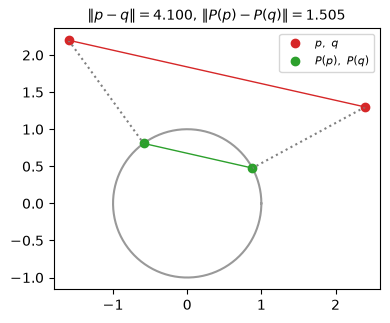

In [7]:
# численная проверка: 1000 случайных пар точек, два множества
def P_ball(z):
    # проекция на единичный шар: z / max(1, ||z||)
    return z / np.maximum(1.0, np.linalg.norm(z, axis=-1, keepdims=True))

def P_cube(z):
    # проекция на куб [-1, 1]^n: покоординатное усечение
    return np.clip(z, -1.0, 1.0)

print(f"{'множество':>16} | {'нарушений':>10} | {'max отношение':>14} | {'строгая форма':>14}")
for name, P, dim in [("шар в R^3", P_ball, 3), ("шар в R^10", P_ball, 10),
                     ("куб [-1,1]^3", P_cube, 3), ("куб [-1,1]^5", P_cube, 5)]:
    P1 = rng.uniform(-3, 3, (1000, dim))
    Q1 = rng.uniform(-3, 3, (1000, dim))
    u = P(P1) - P(Q1)
    lhs = np.linalg.norm(u, axis=1)              # ||P(p) - P(q)||
    rhs = np.linalg.norm(P1 - Q1, axis=1)        # ||p - q||
    firm = np.einsum("ij,ij->i", P1 - Q1, u)     # (p-q)^T u  — строгая форма (3)
    print(f"{name:>16} | {int(np.sum(lhs > rhs + 1e-12)):>10} | {np.max(lhs / rhs):>14.6f} | "
          f"{int(np.sum(lhs**2 > firm + 1e-12)):>14}")

print("\nнарушений нет ни в одном случае: проекция никогда не растягивает.")
print("Отношение доходит до 1 (куб в R^3) — неравенство нестрогое, равенство достижимо.")
p_in, q_in = np.array([0.3, -0.7, 0.2]), np.array([-0.5, 0.1, 0.9])   # обе точки уже внутри куба
print(f"пример равенства: p, q внутри куба -> P(p) = p, P(q) = q, отношение = "
      f"{np.linalg.norm(P_cube(p_in) - P_cube(q_in)) / np.linalg.norm(p_in - q_in):.6f}")

# иллюстрация: пара точек снаружи шара и их проекции
fig, ax = plt.subplots(figsize=(4, 4))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color="0.6")
pts = np.array([[2.4, 1.3], [-1.6, 2.2]])
proj = P_ball(pts)
ax.plot(*pts.T, "o", color="tab:red", label="$p,\\ q$")
ax.plot(*proj.T, "o", color="tab:green", label="$P(p),\\ P(q)$")
for z, w in zip(pts, proj):
    ax.plot(*np.vstack([z, w]).T, ":", color="0.5")
ax.plot(*pts.T, "-", color="tab:red", lw=1)
ax.plot(*proj.T, "-", color="tab:green", lw=1)
ax.set_aspect("equal"); ax.legend(fontsize=8)
ax.set_title(f"$\\|p-q\\|={np.linalg.norm(pts[0]-pts[1]):.3f}$, "
             f"$\\|P(p)-P(q)\\|={np.linalg.norm(proj[0]-proj[1]):.3f}$", fontsize=10)
plt.tight_layout(); plt.show()

---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).